In [1]:
from functions import *
import matplotlib.pyplot as plt
def get_QLF(z, bin_num, dM, obscured, Mmid = 10.3, smhm_scat = .3, prob_zero = [0,0,0], standev = [.85, .85, .35]):

    qlf = QLF(z, bin_num)
    qlf.get_dNdMstar(smhm_scat)
    qlf.get_SMBM(dM, Mmid)
    qlf.get_dNdMbh()
    qlf.get_dNdL(prob_zero, standev, obscured)
    
    return qlf.LumBins, qlf.dNdL


In [5]:
%prun get_QLF(2,100,.6,.7, Mmid=10.7,standev = [.85,.85,.3])


         4593 function calls (4588 primitive calls) in 0.046 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      101    0.007    0.000    0.007    0.000 functions.py:95(get_Mstar)
        3    0.004    0.001    0.004    0.001 fromnumeric.py:2847(ndim)
        5    0.003    0.001    0.023    0.005 shape_base.py:270(apply_along_axis)
      100    0.002    0.000    0.002    0.000 functions.py:131(gauss_array)
      100    0.002    0.000    0.004    0.000 functions.py:189(get_mean_etas)
       10    0.002    0.000    0.002    0.000 fromnumeric.py:592(transpose)
        1    0.002    0.002    0.002    0.002 necompiler.py:765(evaluate)
       10    0.002    0.000    0.002    0.000 {method 'reshape' of 'numpy.ndarray' objects}
        2    0.002    0.001    0.006    0.003 cosmology.py:2140(sigma)
        3    0.001    0.000    0.001    0.000 {built-in method scipy.interpolate._fitpack._spl_}
        2    0.001    0.001    0.001 

Text(0,0.5,'$\\log \\Phi (Mpc^{-3} mag^{-1})$')

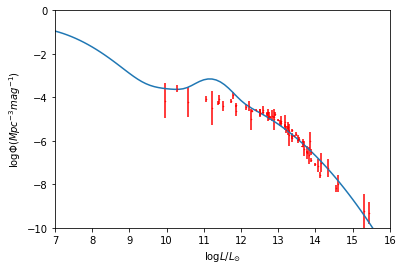

In [88]:
zlist = [0.0, 0.1, 0.2, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0]
z = 2.
xi, yi = get_QLF(z,100,.3,.75, Mmid=10.,standev = [.85,.85,.3])
plt.plot(xi, yi)
x, y , yerr = grab_obs(z)
plt.errorbar(x, y, yerr = yerr, fmt = 'o', markersize = .5,color='r')
plt.axis([7,16,-10,0])
plt.xlabel(r'$\log L/L_{\odot}$')
plt.ylabel(r'$\log \Phi (Mpc^{-3} mag^{-1})$')


MCMC stuff.

In [2]:
import emcee
import corner
import scipy.optimize as op
from functions import *
import matplotlib.pyplot as plt

In [3]:
def model_func(x, p):
    p1, p2 = p
    xm, ym = get_QLF_mcmc(p1, p2)
    y = np.interp(x, xm, ym)
    return y

def lnchi2(p, x, y, err): #lnlike
    
    chi2 = -0.5*np.sum((y-model_func(x,p))**2/(err**2))
    return chi2

def lnprior(p):
    p1, p2 = p
    if 0. < p1 < 3. and 0. < p2 < 1.:
        return 0.0
    return -np.inf

def lnprob(p, x, y, err):
    lp = lnprior(p)
    if np.isfinite(lp):
        return lp + lnchi2(p, x, y, err)
    return -np.inf

z = 3.
bin_num = 200
smhm_scat = .3

qlf = QLF(z, bin_num)
qlf.get_zparams()
qlf.get_dNdMstar(smhm_scat)

### if we go through mcmc for one z value without changing the bin_num of smhm scatter we can do this
def get_QLF_mcmc(dM, obscured, Mmid = 10.3, prob_zero = [0,0,0], standev = [.85, .85, .35]):

    qlf.get_SMBM(dM, Mmid)
    qlf.get_dNdMbh()
    qlf.get_dNdL(prob_zero, standev, obscured)
    
    return qlf.LumBins, qlf.dNdL



In [10]:
xt, yt , yerr = np.array(grab_obs(z))
p = [.5,.5]
ndim, nwalkers = 2, 20

nll = lambda *args: -lnchi2(*args)
result = op.minimize(nll, p, args=(xt, yt, yerr),method = 'Nelder-Mead')

pos = [result["x"] + .1*np.random.randn(ndim) for i in range(nwalkers)]
sampler = emcee.EnsembleSampler(nwalkers, ndim, lnprob, args=(xt,yt,yerr))
sampler.run_mcmc(pos,500)
##more jumps and bigger jumps
##understand results and do a joint fit with all redshifts
##corner plots

print(result)


 final_simplex: (array([[0.47396103, 0.7666021 ],
       [0.47396159, 0.76668088],
       [0.47396269, 0.7665707 ]]), array([55.53897186, 55.53903504, 55.53904082]))
           fun: 55.53897186114615
       message: 'Optimization terminated successfully.'
          nfev: 113
           nit: 59
        status: 0
       success: True
             x: array([0.47396103, 0.7666021 ])


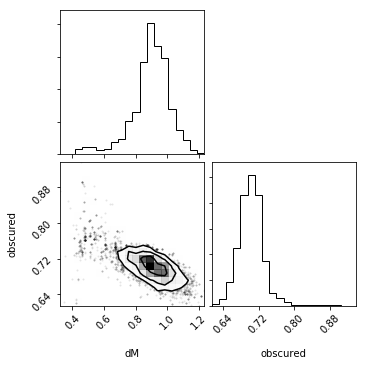

In [11]:
samples = sampler.chain[:,:,:].reshape((-1, ndim))
fig = corner.corner(samples, labels = ['dM','obscured'])
mcmcdM, mcmcObs = np.mean(samples[:,0]), np.mean(samples[:,1])


Text(0,0.5,'$\\log \\Phi (Mpc^{-3} mag^{-1})$')

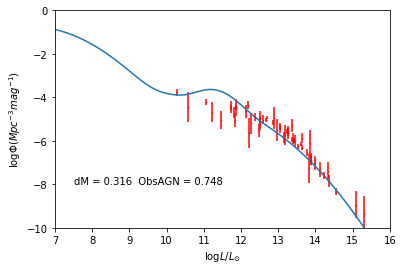

In [23]:
xi, yi = get_QLF_mcmc(mcmcdM, mcmcObs)
plt.plot(xi, yi)
plt.text(7.5,-8,r'dM = '+str(mcmcdM)[:5]+'  ObsAGN = '+str(mcmcObs)[:5])
plt.errorbar(xt, yt, yerr = yerr, fmt = 'o', markersize = .5,color='r')
plt.axis([7,16,-10,0])
plt.xlabel(r'$\log L/L_{\odot}$')
plt.ylabel(r'$\log \Phi (Mpc^{-3} mag^{-1})$')

Stuff I did to fix the interp issue.

13.000000000000007
11.243362186272641 13.000000000000007
12.900000000000007


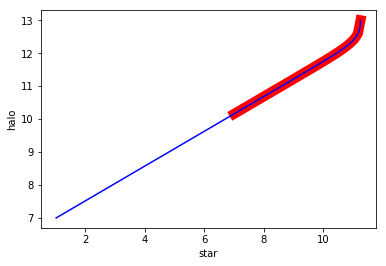

In [13]:
z = 5.
bin_num = 20
Lum = [5,16]
Stell = [7,12]

qlf = QLF(z, bin_num)


max_halo = 15
mhalo = np.linspace(7,max_halo,50)
mstar_h = qlf.get_Mstar(mhalo)

plt.xlabel('star')
plt.ylabel('halo')
stop = np.argmin(sorted(mstar_h) == mstar_h)
while stop != 0:
    max_halo -= .1
    mhalo = np.linspace(7,max_halo,50)
    mstar_h = qlf.get_Mstar(mhalo)
    stop = np.argmin(sorted(mstar_h) == mstar_h)
    
    
max_stell = qlf.get_Mstar(max_halo)
mstar = np.linspace(7,max_stell,50)
mhalo_s = np.interp(mstar, mstar_h, mhalo)
    
plt.plot(mstar, mhalo_s, c='r',linewidth=10)
plt.plot(mstar_h, mhalo, c = 'b')
print(max_stell, max_halo)

slopes = qlf.get_slope(mhalo)
while slopes[-1] < 0:
    max_halo -= .1
    mhalo = np.linspace(7,max_halo,50)
    slopes = qlf.get_slope(mhalo)
print(max_halo)

doing MCMC for lots of redshift.

In [15]:
zlist = [0.0, 0.1, 0.2, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0]
bin_num = 80
smhm_scat = .3

def get_QLF_mcmc(p, i, prob_zero = [0,0,0], standev = [.85, .75, .35]):
    ob = .5
    dm, mmid = p
    i.get_SMBM(dm, mmid)
    i.get_dNdMbh()
    i.get_dNdL(prob_zero, standev, ob)
    
    return i.LumBins, i.dNdL

def model_func_op(x, p, i):
    xm, ym = get_QLF_mcmc(p, i)
    y = np.interp(x, xm, ym)
    return y

def lnchi2_op(p, i, x, y, err): #lnlike
    
    chi2 = -0.5 * np.sum((y - model_func_op(x, p, i)) ** 2 / (err ** 2))
    return chi2

qlf_00 = QLF(0.0, bin_num)
qlf_01 = QLF(0.1, bin_num)
qlf_02 = QLF(0.2, bin_num)
qlf_05 = QLF(0.5, bin_num)    
qlf_10 = QLF(1.0, bin_num)
qlf_15 = QLF(1.5, bin_num)
qlf_20 = QLF(2.0, bin_num)
qlf_25 = QLF(2.5, bin_num)
qlf_30 = QLF(3.0, bin_num)
qlf_35 = QLF(3.5, bin_num)
qlf_40 = QLF(4.0, bin_num)
qlf_45 = QLF(4.5, bin_num)
qlf_50 = QLF(5.0, bin_num)
qlf_55 = QLF(5.5, bin_num)
qlf_60 = QLF(6.0, bin_num)

qlf_list = [qlf_00, qlf_01, qlf_02, qlf_05, qlf_10, qlf_15, qlf_20, qlf_25, qlf_30, qlf_35, qlf_40, qlf_45, qlf_50, qlf_55, qlf_60]

for i in qlf_list:
    i.get_dNdMstar(smhm_scat)

xt_tot = []
yt_tot = []
yerr_tot = []
z_tot = []
for z in zlist:
    x, y, yerr = grab_obs(z)
    xt_tot.extend(x)
    yt_tot.extend(y)
    yerr_tot.extend(yerr)
    for j in range(len(x)):
        z_tot.append(z)

p = [1.5, 10.0]
nll = lambda *args: -lnchi2_op(*args)
results = []
for i, z in zip(qlf_list, zlist):
    xt, yt, yerr = np.array(grab_obs(z))
    results.append(op.minimize(nll, p, args=(i, xt, yt, yerr), method = 'Nelder-Mead')["x"])


In [16]:
def lnprior(p):
    dm, ob, mmid = p
    if 0.0 < dm <= 3.0 and 0.5 < ob < 1.0 and 10. < mmid < 10.8:
        return 0.0
    return -np.inf

def lnprob(p, i, x, y, err):
    lp = lnprior(p)
    if np.isfinite(lp):
        return lp + lnchi2(p, i, x, y, err)
    return -np.inf

def lnchi2(p, z, x, y, err): #lnlike
    
    chi2 = np.sum((y - model_func(x, p, z)) ** 2 / (err ** 2)) / (len(x)-1)
    return np.log(chi2)

def model_func(x, p, z, prob_zero = [0,0,0], standev = [.85, .75, .35]):
    y = []
    dm, ob, mmid = p
    z = np.array(z)
    for zs, i in zip(zlist, qlf_list):
        i.get_SMBM(dm, mmid)
        i.get_dNdMbh()
        i.get_dNdL(prob_zero, standev, ob)
        xm, ym = i.LumBins, i.dNdL
        where = (z == zs)  
        y.extend(np.interp(np.array(x)[where], xm, ym))
    return y



In [ ]:
from numpy.random import randint as rnint
from numpy.random import random_sample as rnsamp
ndim, nwalkers, steps = 3, 100, 200
myp = [1.5, .7, 10.4]
pos = [np.array([(myp[0] + np.random.randint(-1,2)*np.random.random_sample(1)*1.)[0], myp[1] + (np.random.randint(-1,2)*np.random.random_sample(1)*.2)[0], (myp[2] + np.random.randint(-1,2)*np.random.random_sample(1)*.4)[0]]) for n in range(nwalkers)]

print('start sampler')
sampler1 = emcee.EnsembleSampler(nwalkers, ndim, lnprob, args=(np.array(z_tot), np.array(xt_tot), np.array(yt_tot), np.array(yerr_tot)))
%time sampler1.run_mcmc(pos, steps)
samples1 = sampler1.chain[:,:,:].reshape((-1,ndim))
print('end sampler')


start sampler


[0.655 0.65  0.63  0.72  0.565 0.665 0.6   0.66  0.595 0.72  0.605 0.585
 0.7   0.465 0.58  0.465 0.64  0.615 0.49  0.425 0.51  0.67  0.615 0.575
 0.635 0.455 0.695 0.69  0.38  0.595 0.62  0.63  0.635 0.655 0.63  0.58
 0.57  0.615 0.67  0.64  0.665 0.605 0.555 0.51  0.54  0.5   0.405 0.685
 0.625 0.7   0.515 0.725 0.515 0.6   0.565 0.57  0.675 0.45  0.635 0.725
 0.5   0.605 0.66  0.565 0.43  0.695 0.73  0.61  0.54  0.455 0.57  0.485
 0.44  0.485 0.56  0.67  0.63  0.38  0.735 0.455 0.635 0.585 0.565 0.68
 0.365 0.535 0.7   0.705 0.7   0.72  0.58  0.515 0.35  0.69  0.37  0.605
 0.775 0.565 0.715 0.695]


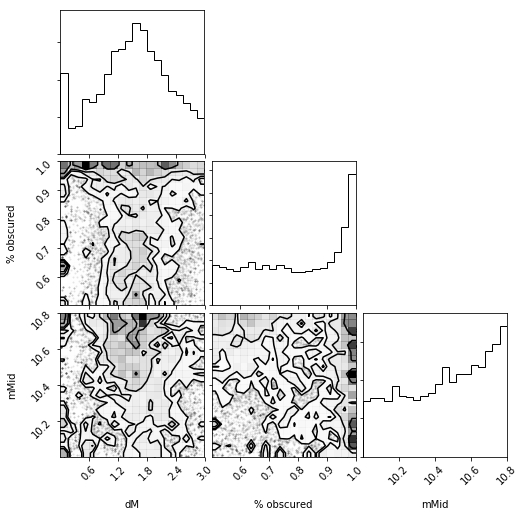

In [38]:
print(sampler1.acceptance_fraction)
fig = corner.corner(samples1, labels = ['dM','% obscured', 'mMid'])

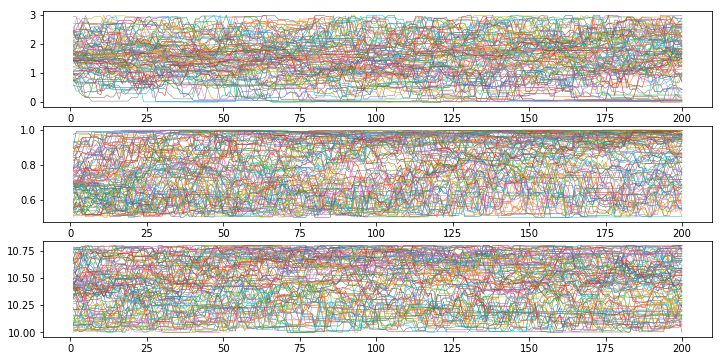

In [39]:

import matplotlib.gridspec as gridspec

gs = gridspec.GridSpec(3, 1)
fig = plt.figure(figsize=(12,6))

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[1, 0])
ax2 = fig.add_subplot(gs[2, 0])

for w in sampler1.chain[:,:,:]:
    dmy = []
    oby = []
    mmidy = []
    for y in w:
        dmy.append(y[0])
        oby.append(y[1])
        mmidy.append(y[2])
    x = np.linspace(1,steps,steps)
    ax0.plot(x,dmy,linewidth=0.5)
    ax1.plot(x,oby,linewidth=0.5)
    ax2.plot(x,mmidy,linewidth=0.5)

In [25]:
print(myp[0] + np.random.randint(-1,2)*np.random.random_sample(1)*1.)

[1.5]


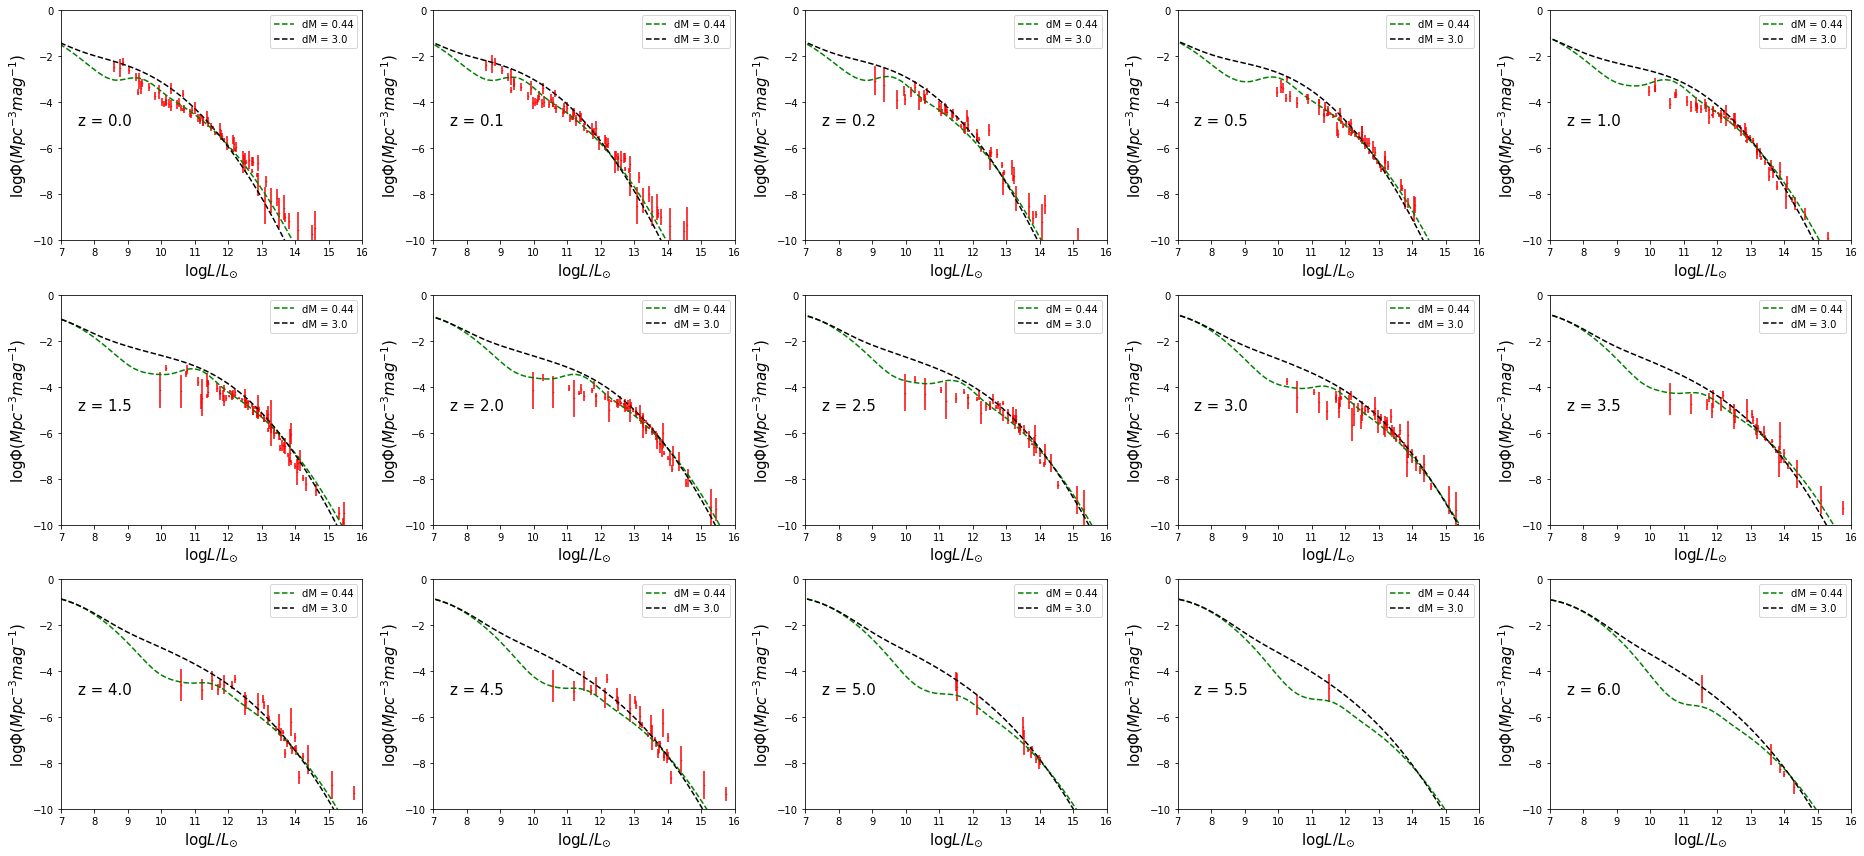

In [14]:
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(26,12))
gs = gridspec.GridSpec(3, 5)
fs = 15
mcmc_dM_l = [0.44, 3.0]
for z, i, j in zip(zlist,[0,0,0,0,0,1,1,1,1,1,2,2,2,2,2],[0,1,2,3,4,0,1,2,3,4,0,1,2,3,4]):

    xt, yt , yerr = np.array(grab_obs(z))   
    ax = fig.add_subplot(gs[i, j])
    for dM,c in zip(mcmc_dM_l,['g','k']):
        xm, ym = get_QLF(z, bin_num, dM = dM, obscured = .75, Mmid = 10.3, smhm_scat = .3, prob_zero = [0,0,0], standev = [.85, .85, .35])
        ax.plot(xm,ym,label='dM = '+str(dM),linestyle='dashed',color=c)
    ax.set_xlabel(r'$\log L/L_{\odot}$',fontsize=fs)
    ax.set_ylabel(r'$\log \Phi (Mpc^{-3} mag^{-1})$',fontsize=fs)
    ax.text(7.5,-5,'z = '+str(z),fontsize=fs)
    ax.errorbar(xt, yt, yerr = yerr, fmt = 'o', markersize = .5,color='r')
    ax.axis([7,16,-10,0])
    ax.legend()
        
plt.tight_layout()
plt.savefig('plots/MCMC_dM_QLF_v1.0.pdf')
